In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_columns", None)

In [4]:
sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("german_credit_data.csv")

In [6]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 115.1 KB


In [8]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df["Job"].unique()

array([2, 1, 3, 0])

In [11]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.dropna().reset_index(drop=True)

In [14]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [15]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [16]:
df.drop(columns = 'Unnamed: 0' , inplace = True)

In [17]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

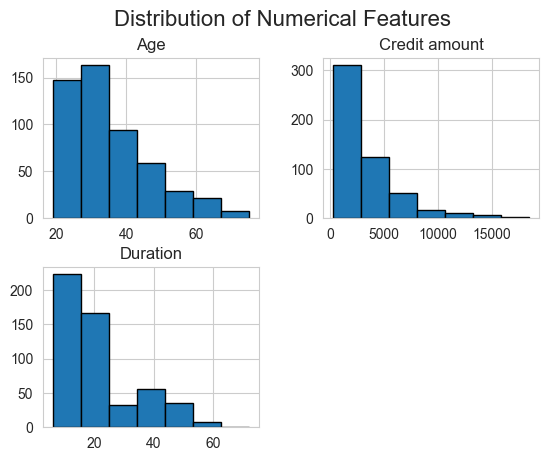

In [18]:
df[["Age", "Credit amount", "Duration"]].hist(bins = 7, edgecolor = "black")
plt.suptitle("Distribution of Numerical Features", fontsize = 16)
plt.show()

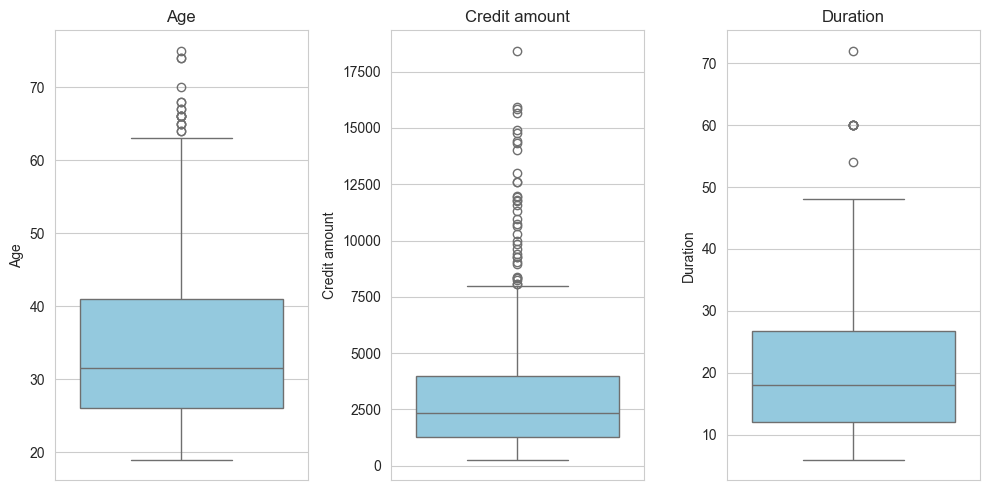

In [19]:
plt.figure(figsize = (10,5))
for i , col in enumerate (("Age", "Credit amount", "Duration")):
    plt.subplot(1,3,i+1)
    sns.boxplot(y = df[col], color = "skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [20]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [21]:
categorical_cols = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

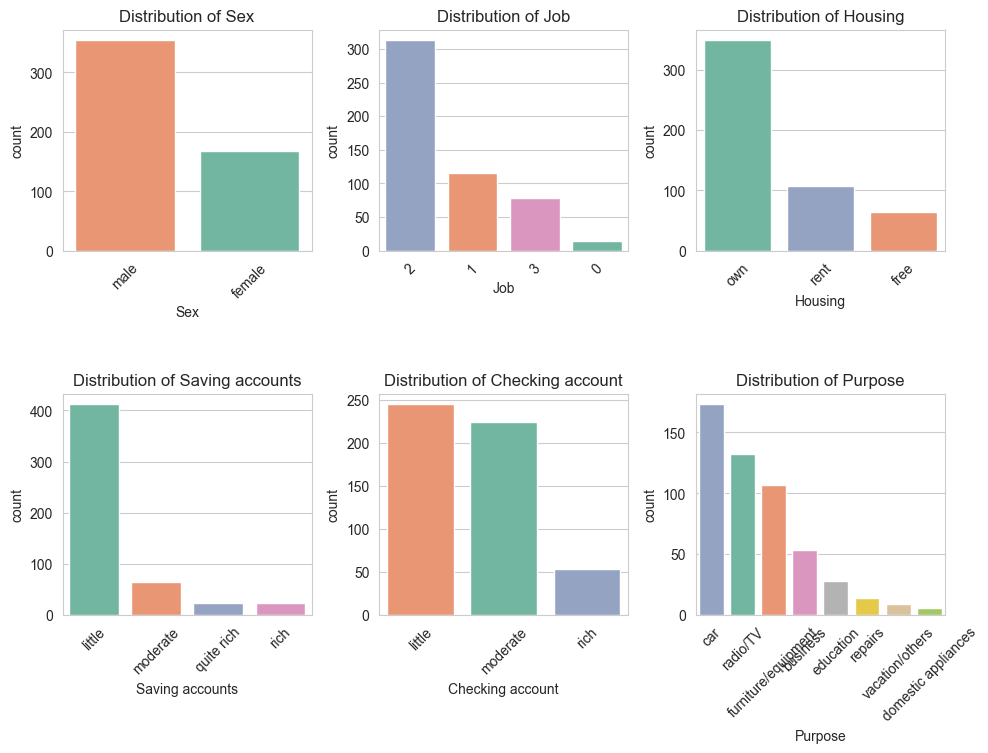

In [22]:
plt.figure(figsize = (10,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data = df, x = col, hue = col, legend=False, palette = "Set2", order = df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

In [23]:
corr = df[["Age", "Job", "Credit amount", "Duration"]].corr()

In [24]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


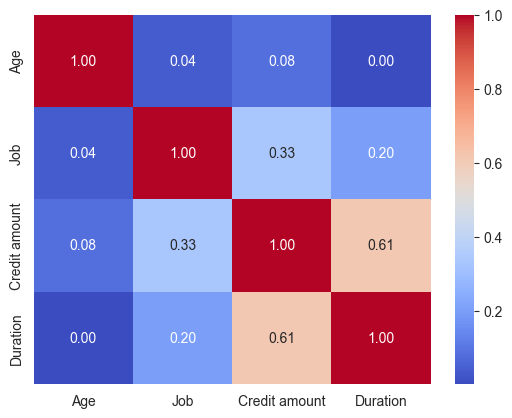

In [25]:
sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.show()

In [26]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [27]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [28]:
pd.pivot_table(df, values = "Credit amount", index = "Housing", columns = "Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


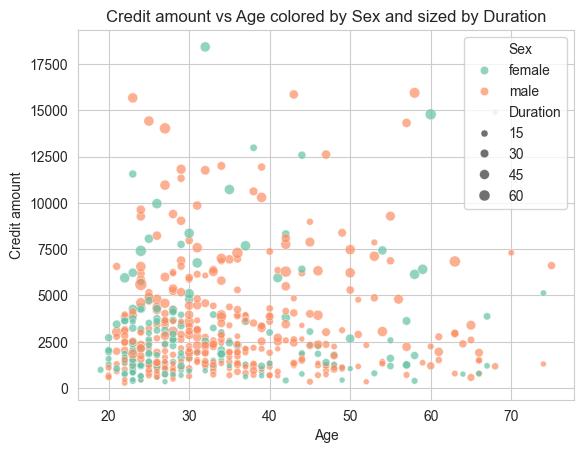

In [29]:
sns.scatterplot(data = df, x = "Age", y = "Credit amount", hue = "Sex", size = "Duration", alpha = 0.7, palette = "Set2")
plt.title("Credit amount vs Age colored by Sex and sized by Duration")
plt.show()

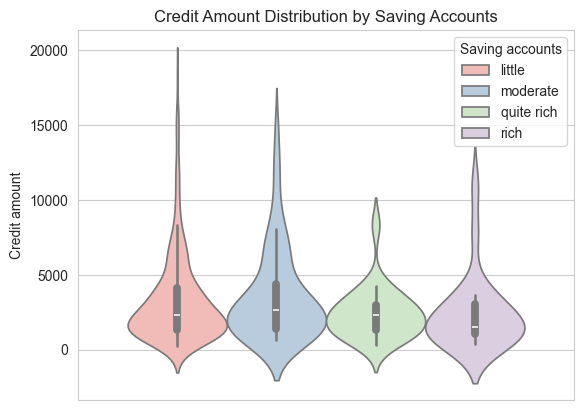

In [30]:
sns.violinplot(data = df, hue = "Saving accounts", y = "Credit amount", palette = "Pastel1")
plt.title("Credit Amount Distribution by Saving Accounts")
plt.show()

In [31]:
df["Risk"].value_counts(normalize = True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

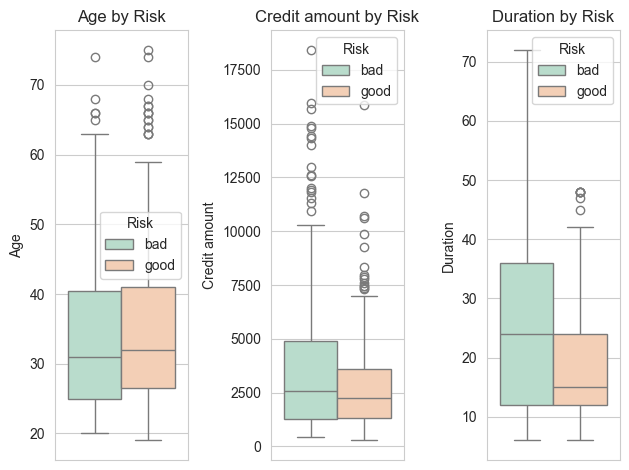

In [32]:
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data = df, hue = "Risk", y = col, palette = "Pastel2")
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [33]:
df.groupby("Risk")[["Age","Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [34]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

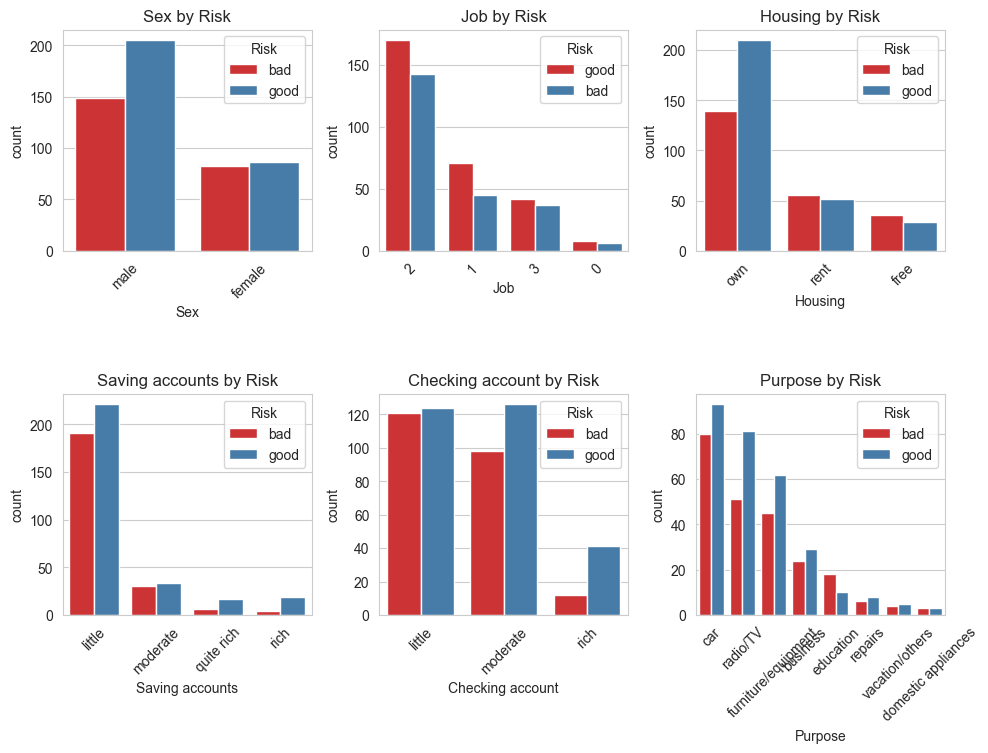

In [35]:
plt.figure(figsize=(10,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3, i+1)
    sns.countplot(data = df, x = col, hue = "Risk", palette = "Set1", order = df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

In [36]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [37]:
features = ["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account","Credit amount","Duration"]

In [38]:
target = "Risk"

In [39]:
df_model = df[features + [target]].copy()

In [40]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [41]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [42]:
cat_cols = df_model.select_dtypes(include=["object", "string"]).columns.drop("Risk")

In [43]:
le_dict = {}

In [44]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [45]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

In [46]:
le_target = LabelEncoder()


In [47]:
target

'Risk'

In [48]:
df_model[target] = le_target.fit_transform(df_model[target])

In [49]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [50]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [51]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [52]:
from sklearn.model_selection import train_test_split

In [53]:
x = df_model.drop(target, axis = 1)
y = df_model[target]

In [54]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2, stratify=y, random_state = 1)

In [55]:
x_train.shape

(417, 8)

In [56]:
x_test.shape

(105, 8)

In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [58]:
def train_model(model, param_grid, x_train, y_train, x_test, y_test):
    grid = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy", n_jobs = -1)
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [59]:
dt = DecisionTreeClassifier(random_state = 1, class_weight = "balanced")
dt_param_grid= {
    "max_depth" : [3,5,7,10,None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,4]
}

In [60]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, x_train, y_train, x_test, y_test)

In [61]:
print("Decision Tree Accuracy", acc_dt)

Decision Tree Accuracy 0.580952380952381


In [62]:
print("Best parameters", params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [63]:
rf = RandomForestClassifier(random_state = 1, class_weight = "balanced", n_jobs = -1)

In [64]:
rf_param_grid = {
    "n_estimators" : [100,200],
    "max_depth" : [5,7,10,None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,4]    
}

In [65]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, x_train, y_train, x_test, y_test)

In [66]:
print("Random Forest Acciracu",acc_rf)

Random Forest Acciracu 0.6190476190476191


In [67]:
print("Best params", params_rf)

Best params {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [68]:
et = ExtraTreesClassifier(random_state = 1, class_weight = "balanced", n_jobs = -1)

In [69]:
et_param_grid = {
    "n_estimators" : [100,200],
    "max_depth" : [5,7,10,None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,4]    
}

In [70]:
best_et, acc_et, params_et = train_model(et, et_param_grid, x_train, y_train, x_test, y_test)

In [71]:
print("Extra trees accuracy", acc_et)

Extra trees accuracy 0.6476190476190476


In [72]:
print("Best params: ", params_et)

Best params:  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [73]:
xgb = XGBClassifier(random_state=1,scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),eval_metric="logloss")

In [74]:
xgb_param_grid ={
    "n_estimators" : [100, 200],
    "max_depth" : [3,5,7],
    "learning_rate" : [0.01,0.1,0.2],
    "subsample" : [0.7,1],
    "colsample_bytree" : [0.7,1],
}

In [75]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, x_train, y_train,x_test, y_test)

In [76]:
print("XGB accuracy", acc_xgb)

XGB accuracy 0.6761904761904762


In [77]:
print("Best params", params_xgb)

Best params {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


In [78]:
best_et.predict(x_test)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1])

In [79]:
joblib.dump(best_et, "extra_trees_credit_model.pkl")

['extra_trees_credit_model.pkl']